In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# 1. Data Cleaning

In [2]:
df = pd.read_excel("data/2023_MCM_Problem_C_Data.xlsx", header=1) 
df.head()

,Unnamed: 0,Date,Contest number,Word,Number of reported results,Number in hard mode,1 try,2 tries,3 tries,4 tries,5 tries,6 tries,7 or more tries (X)
0,NaN,2022-12-31,560,manly,20380,1899,0,2,17,37,29,12,2
1,NaN,2022-12-30,559,molar,21204,1973,0,4,21,38,26,9,1
2,NaN,2022-12-29,558,havoc,20001,1919,0,2,16,38,30,12,2
3,NaN,2022-12-28,557,impel,20160,1937,0,3,21,40,25,9,1
4,NaN,2022-12-27,556,condo,20879,2012,0,2,17,35,29,14,3


## 1.1 Rename columns

In [3]:
df = df.drop(columns=["Unnamed: 0"])
df = df.rename(columns={
    'Date': 'date', 
    'Contest number': 'contest_num', 
    'Word': 'word', 
    'Number of  reported results': 'n_reported', 
    'Number in hard mode': 'n_hard',
    '1 try': 'try_1',
    '2 tries': 'try_2',
    '3 tries': 'try_3',
    '4 tries': 'try_4',
    '5 tries': 'try_5',
    '6 tries': 'try_6',
    '7 or more tries (X)': 'try_x',
})
df.head()

,date,contest_num,word,n_reported,n_hard,try_1,try_2,try_3,try_4,try_5,try_6,try_x
0,2022-12-31,560,manly,20380,1899,0,2,17,37,29,12,2
1,2022-12-30,559,molar,21204,1973,0,4,21,38,26,9,1
2,2022-12-29,558,havoc,20001,1919,0,2,16,38,30,12,2
3,2022-12-28,557,impel,20160,1937,0,3,21,40,25,9,1
4,2022-12-27,556,condo,20879,2012,0,2,17,35,29,14,3


## 1.2 Handling invalid data

Add a zero to 30.11 `n_reported` (word 'study')


In [4]:
df.loc[df['word'] == 'study', "n_reported"] = 25690

Replace invalid words:
* 26.11 clen -> clean
* 16.12 rprobe -> probe
* 29.4 tash -> trash
* 12.1 “favor “ -> favor
* 10.5 marxh -> march


In [5]:
df.loc[df['word'] == 'rprobe', "word"] = "probe"
df.loc[df['word'] == 'tash', "word"] = "trash"
df.loc[df['word'] == 'favor ', "word"] = "favor"
df.loc[df['word'] == 'clen', "word"] = "clean"
df.loc[df['word'] == 'marxh', "word"] = "march"

Remove 27.3 (invalid sum of values in number of tries)

In [6]:
df = df[df['date'] != '2022-03-27']

# 2. Data Exploration

## 2.1 Outliers

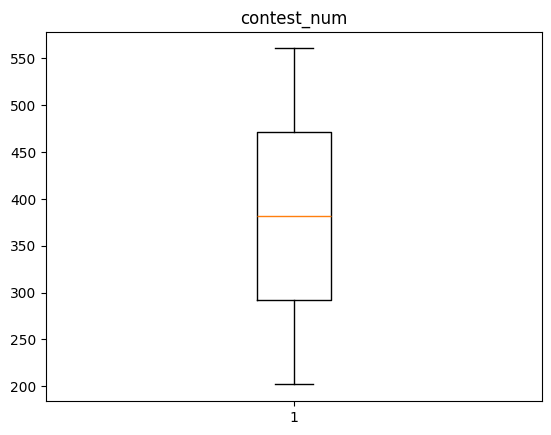

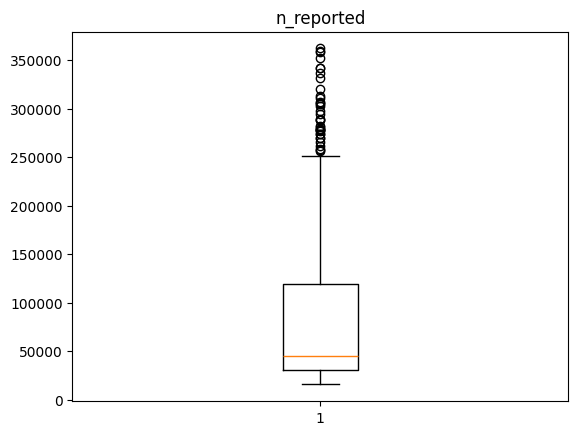

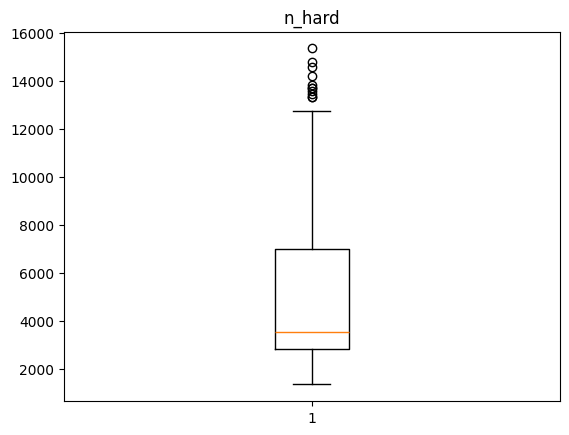

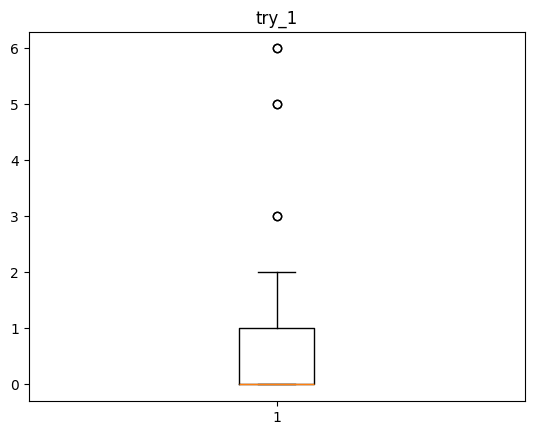

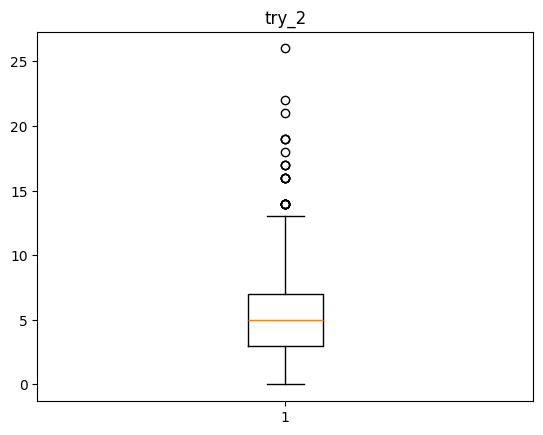

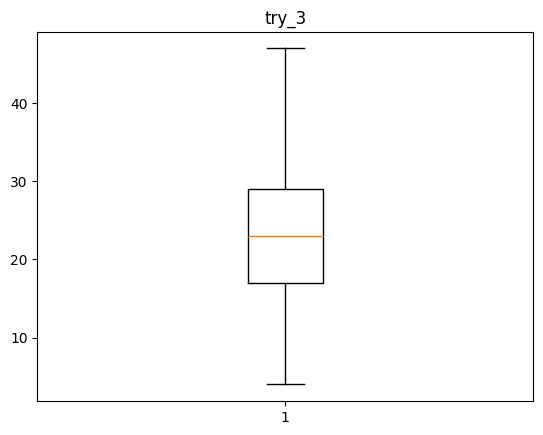

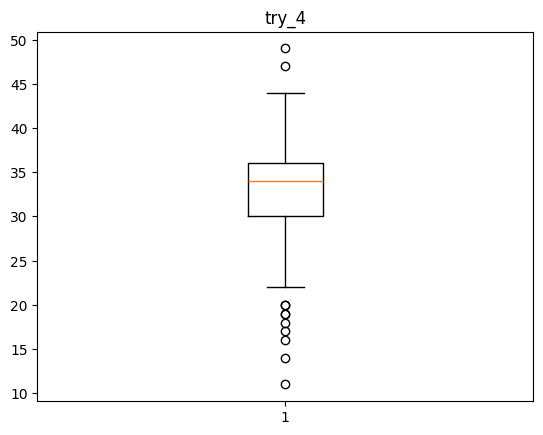

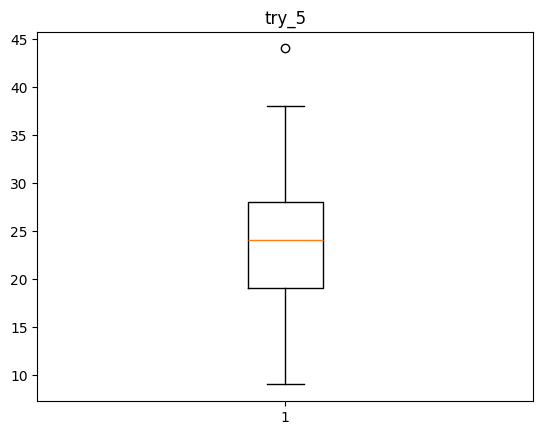

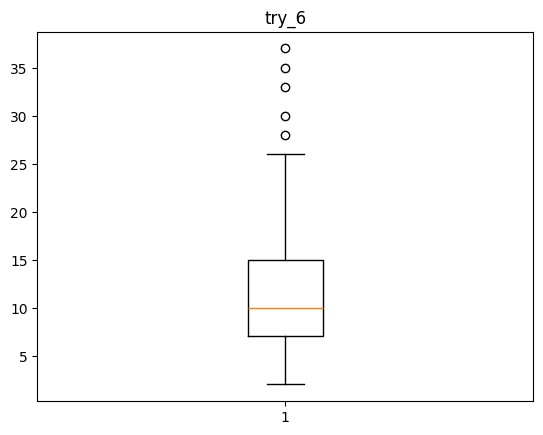

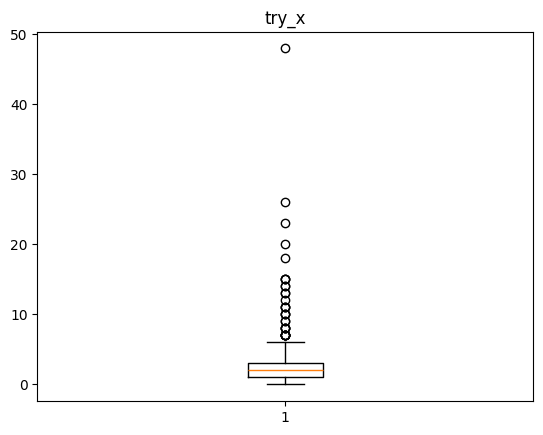

In [7]:
numeric_df = df.select_dtypes(include='number')

for col in numeric_df.columns:
    plt.figure()
    plt.boxplot(numeric_df[col].dropna())
    plt.title(col)
    plt.show()

In [8]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

outlier_counts = df.select_dtypes(include='number').apply(count_outliers).sort_values(ascending=False)

print(outlier_counts)

n_reported     36
try_x          32
try_2          24
n_hard         11
try_4          11
try_1           6
try_6           5
try_5           1
contest_num     0
try_3           0
dtype: int64


## 2.2 Distribution of number of tries per example

In [9]:
def plot_tries_with_normal_dist(df, word):
    cols = [
        "try_1",
        "try_2",
        "try_3",
        "try_4",
        "try_5",
        "try_6",
        "try_x"
    ]
    
    y_values = df.loc[df['word'] == word, cols].values.astype(float).flatten()
    
    # Create numerical x-values corresponding to the tries (1 to 7)
    x_num = np.array([1, 2, 3, 4, 5, 6, 7])
    
    # Calculate weighted mean and standard deviation
    total_count = np.sum(y_values)

    # Prevent division by zero if row is empty
    if total_count == 0:
        print(f"No data for word: {word}")
        return
        
    mean = np.sum(x_num * y_values) / total_count
    variance = np.sum(y_values * (x_num - mean)**2) / total_count
    std = np.sqrt(variance)
    
    plt.figure()
    # Plot the actual data as a bar chart
    sns.barplot(x=cols, y=y_values, color='skyblue', alpha=0.7, label='Actual Distribution')
    
    # Generate points for the normal distribution curve
    x_smooth = np.linspace(0.5, 7.5, 100)
    # Calculate the normal PDF and scale it by total_count
    y_normal = norm.pdf(x_smooth, mean, std) * total_count 
    # Plot the normal curve (subtract 1 from x_smooth to align with categorical x-axis)
    plt.plot(x_smooth - 1, y_normal, 'r-', lw=2, 
             label=rf'Normal Dist ($\mu=${mean:.2f}, $\sigma=${std:.2f})')
    
    plt.xlabel('Number of Tries', fontsize=12)
    plt.ylabel('Value / Frequency', fontsize=12)
    
    plt.title(f'Distribution of Tries for "{word}"', fontsize=15, fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    
    return mean, std

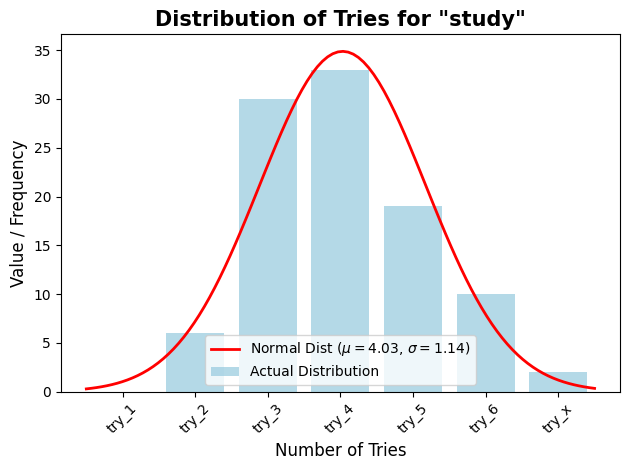

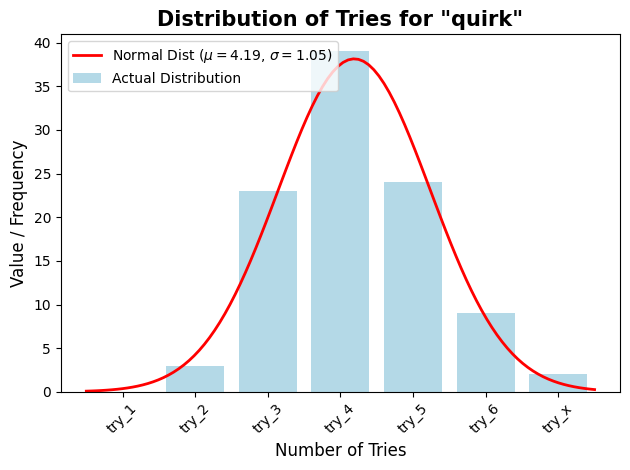

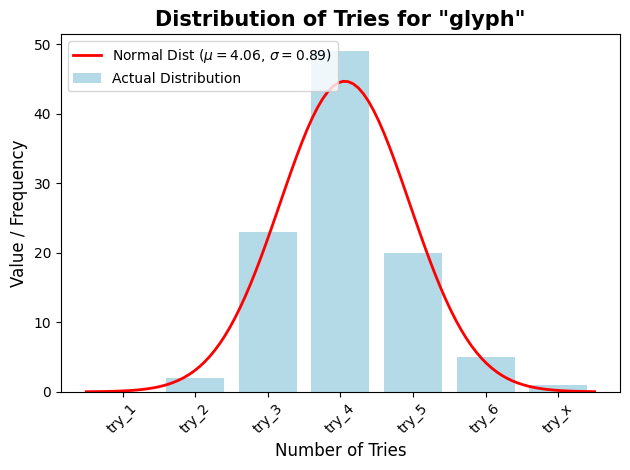

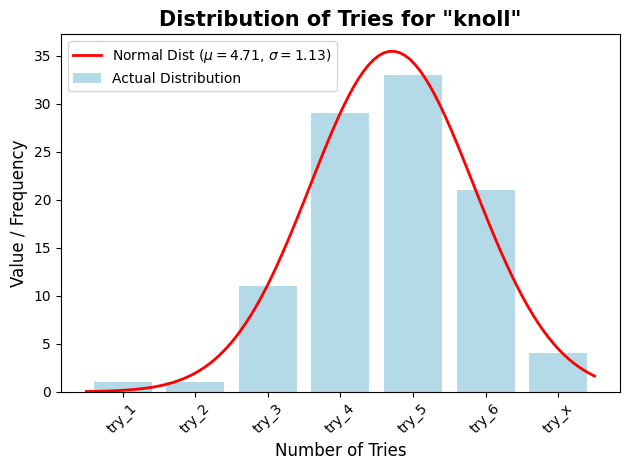

In [10]:
for w in ['study', 'quirk', 'glyph', 'knoll']:
    plot_tries_with_normal_dist(df, word=w)

In [11]:
df.to_csv('data/cleaned.csv', index=False)